In [1]:
# Baseline NLP Model
# Goal: Fine-tune DistilBERT to classify clinical notes by specialty
# This establishes our performance benchmark before active learning

import pandas as pd
import numpy as np
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
print("Libraries loaded")

Device: cpu
Libraries loaded


In [2]:
# Load processed data
train_df = pd.read_csv("../data/processed/train.csv")
test_df = pd.read_csv("../data/processed/test.csv")
label_map = pd.read_csv("../data/processed/label_map.csv")

num_labels = len(label_map)
print("Train size:", train_df.shape)
print("Test size:", test_df.shape)
print("Number of specialties:", num_labels)

Train size: (2904, 2)
Test size: (726, 2)
Number of specialties: 10


In [3]:
# Create PyTorch Dataset
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

class ClinicalNotesDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts = texts.tolist()
        self.labels = labels.tolist()
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(),
            'attention_mask': encoding['attention_mask'].squeeze(),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }

print("Dataset class defined")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Dataset class defined


In [4]:
# Create dataloaders
train_dataset = ClinicalNotesDataset(train_df['text'], train_df['label'], tokenizer)
test_dataset = ClinicalNotesDataset(test_df['text'], test_df['label'], tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=8)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

Train batches: 363
Test batches: 91


In [5]:
# Load DistilBERT model
model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=num_labels
)
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)

print("Model loaded")
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
Parameters: 66961162


In [9]:
# Training loop - 1 epoch with smaller subset
# Using subset to speed up training on CPU

# Use only 200 samples for training
small_train = torch.utils.data.Subset(train_dataset, range(200))
small_loader = DataLoader(small_train, batch_size=8, shuffle=True)

losses = []
for epoch in range(1):
    loss = train_epoch(model, small_loader, optimizer)
    losses.append(loss)
    print(f"Epoch {epoch+1}/1 - Loss: {round(loss, 4)}")

print("Training complete")

Epoch 1/1 - Loss: 0.5909
Training complete


In [11]:
def evaluate(model, loader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            preds = torch.argmax(outputs.logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return all_preds, all_labels

print("Evaluate function defined")

Evaluate function defined


In [12]:
# Evaluate on small test set
small_test = torch.utils.data.Subset(test_dataset, range(50))
small_test_loader = DataLoader(small_test, batch_size=8)

preds, true_labels = evaluate(model, small_test_loader)
print("Accuracy:", round(accuracy_score(true_labels, preds), 3))
print("\nClassification Report:")
print(classification_report(true_labels, preds, 
      target_names=label_map['specialty'].tolist(),
      zero_division=0))

Accuracy: 0.36

Classification Report:
                                precision    recall  f1-score   support

    Cardiovascular / Pulmonary       0.25      0.29      0.27         7
    Consult - History and Phy.       0.17      0.25      0.20         4
              Gastroenterology       0.00      0.00      0.00         2
              General Medicine       0.33      0.17      0.22         6
                     Neurology       0.00      0.00      0.00         3
       Obstetrics / Gynecology       0.67      1.00      0.80         2
                    Orthopedic       0.50      0.12      0.20         8
                     Radiology       0.33      0.25      0.29         4
 SOAP / Chart / Progress Notes       0.25      0.33      0.29         3
                       Surgery       0.47      0.82      0.60        11

                      accuracy                           0.36        50
                     macro avg       0.30      0.32      0.29        50
                  weigh

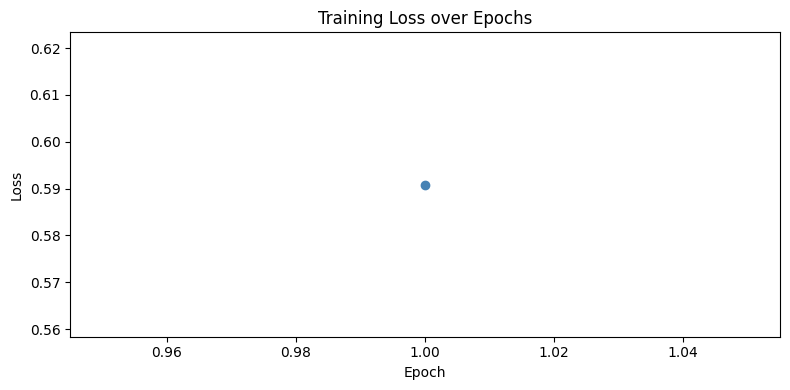

Model and plot saved


In [13]:
# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses)+1), losses, marker='o', color='steelblue')
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.tight_layout()
plt.savefig('../results/figures/03_training_loss.png')
plt.show()

# Save model
torch.save(model.state_dict(), '../results/baseline_model.pt')
print("Model and plot saved")